# `techa` — User Guide

Technical analysis primitives for quantitative trading.

```
techa/
│
├── techa.indicators      Last-bar indicator snapshot (TA-Lib backed)
│   ├── build_snapshot(ohlcv, *, nan_to_none)         → dict
│   ├── build_snapshot_from_parquet(ticker, path, …)  → dict
│   ├── build_ticker_snapshot(data)                   → pd.DataFrame
│   └── build_group_snapshot(data, groups, …)         → GroupSnapshot
│
└── techa.patterns        Candlestick scanner + visualizer (61 TA-Lib patterns)
    ├── scan_patterns(ohlcv, patterns, signal_filter)  → pd.DataFrame
    ├── scan_last_bar(ohlcv_by_ticker, …)              → pd.DataFrame
    ├── plot_pattern(ohlcv, pattern, …)                → None
    └── explore_patterns(ohlcv, patterns, …)           → None
```

## Sections
1. [Setup & Data](#1--setup--data)
2. [techa.indicators](#2--techaindicators)
   - 2.1 build_snapshot
   - 2.2 build_ticker_snapshot
   - 2.3 build_group_snapshot & GroupSnapshot
3. [techa.patterns](#3--techapatterns)
   - 3.1 scan_patterns
   - 3.2 scan_last_bar
   - 3.3 plot_pattern
   - 3.4 explore_patterns
4. [Morning Routine — Combined](#4--morning-routine)
5. [Error Handling](#5--error-handling)

## 1 — Setup & Data

In [1]:
import os

import pandas as pd
import yfinance as yf
from IPython.display import Image, display

# Download ~2 years of daily OHLCV for three demo tickers
TICKERS = ["SIE.DE", "STMMI.MI", "PRY.MI"]

ohlcv = {
    t: yf.download(t, start="2022-01-01", end="2024-12-31", multi_level_index=False)
    for t in TICKERS
}

for t, df in ohlcv.items():
    print(f"{t:12s}  {len(df)} bars  ({df.index[0].date()} → {df.index[-1].date()})")

ohlcv["SIE.DE"].tail(3)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

SIE.DE        766 bars  (2022-01-03 → 2024-12-30)
STMMI.MI      763 bars  (2022-01-03 → 2024-12-30)
PRY.MI        763 bars  (2022-01-03 → 2024-12-30)


,Close,High,Low,Open,Volume
Date,,,,,
2024-12-23,180.815430,181.963583,180.069129,180.987661,788599
2024-12-27,181.408646,181.485177,179.380227,179.686409,684363
2024-12-30,181.408646,181.408646,181.408646,181.408646,0


## 2 — techa.indicators

Last-bar technical indicator snapshots from raw OHLCV data.
Backed by TA-Lib. Requires ≥ 30 bars (`MIN_BARS`).

| Function | Input | Output |
|---|---|---|
| `build_snapshot` | Single-ticker OHLCV DataFrame | `dict` of scalars |
| `build_snapshot_from_parquet` | Parquet path + ticker name | `dict` (loads & filters internally) |
| `build_ticker_snapshot` | `{ticker: ohlcv_df}` dict | `pd.DataFrame` indexed by ticker |
| `build_group_snapshot` | `{ticker: ohlcv_df}` dict | `GroupSnapshot` dataclass |

### 2.1 — `build_snapshot`

Returns a flat `dict` of ~30 scalar indicators for the **last bar** of the input series.
Pass `nan_to_none=True` for JSON-serialisable output (TA-Lib lookback gaps → `None`).

In [2]:
from techa.indicators import build_snapshot

snap = build_snapshot(ohlcv["SIE.DE"], nan_to_none=True)
pd.Series(snap)

price                 181.408646
sma20                 182.419975
sma50                 177.319675
sma200                168.461364
ema20                 181.330134
ema50                 177.588811
dist_sma20_pct         -0.554396
dist_sma50_pct          2.305988
dist_sma200_pct         7.685609
slope_sma20             0.305432
slope_sma20_r2          0.985919
adx                    25.429286
di_plus                28.901508
di_minus               22.335977
golden_cross                True
rsi                    52.328465
rsi_zone                 neutral
macd                    1.563075
macd_signal             2.227135
macd_hist               -0.66406
stoch_k                28.506377
stoch_d                30.028267
stoch_fast_k            47.70661
stoch_fast_d           35.175275
roc_10d                 -3.02782
roc_20d                 5.933632
chg_1d                       0.0
chg_5d                 -2.629419
atr                     3.088824
atr_pct                 1.702688
bb_upper  

In [3]:
# ── Trend ──────────────────────────────────────────────────────────────────
trend_keys = [
    "adx", "di_plus", "di_minus", "golden_cross",
    "dist_sma20_pct", "dist_sma50_pct", "dist_sma200_pct",
    "slope_sma20", "slope_sma20_r2",
]
print("TREND")
for k in trend_keys:
    print(f"  {k:<24} {snap[k]}")

# ── Momentum ────────────────────────────────────────────────────────────────
mom_keys = ["rsi", "rsi_zone", "macd", "macd_hist",
            "stoch_k", "stoch_d", "roc_10d", "roc_20d", "chg_1d", "chg_5d"]
print("\nMOMENTUM")
for k in mom_keys:
    print(f"  {k:<24} {snap[k]}")

# ── Volatility ──────────────────────────────────────────────────────────────
vol_keys = ["atr", "atr_pct", "bb_upper", "bb_mid", "bb_lower",
            "bb_width", "bb_pct_b", "hist_vol_20d"]
print("\nVOLATILITY")
for k in vol_keys:
    print(f"  {k:<24} {snap[k]}")

# ── Volume ──────────────────────────────────────────────────────────────────
print("\nVOLUME")
for k in ["volume", "vol_vs_ma20", "obv"]:
    print(f"  {k:<24} {snap[k]}")

TREND
  adx                      25.429285800787202
  di_plus                  28.90150757870582
  di_minus                 22.335976980576806
  golden_cross             True
  dist_sma20_pct           -0.5543959155857879
  dist_sma50_pct           2.305987945307386
  dist_sma200_pct          7.685608791313368
  slope_sma20              0.30543191898999145
  slope_sma20_r2           0.9859190826185761

MOMENTUM
  rsi                      52.32846531835634
  rsi_zone                 neutral
  macd                     1.5630751585777034
  macd_hist                -0.6640601661431917
  stoch_k                  28.50637669177927
  stoch_d                  30.028267076223795
  roc_10d                  -3.0278202102315133
  roc_20d                  5.933632145708145
  chg_1d                   0.0
  chg_5d                   -2.629419128580257

VOLATILITY
  atr                      3.0888237532692386
  atr_pct                  1.7026882828788548
  bb_upper                 189.90031670697797
  

### 2.2 — `build_ticker_snapshot`

Runs `build_snapshot` on every ticker in the dict and assembles the results into a
DataFrame indexed by ticker. Tickers with < 30 bars are **skipped with a warning** —
one bad ticker never aborts a multi-ticker scan.

In [4]:
from techa.indicators import build_ticker_snapshot

ticker_df = build_ticker_snapshot(ohlcv)

# Side-by-side comparison of key indicators
ticker_df[[
    "price", "rsi", "rsi_zone", "adx",
    "vol_vs_ma20", "hist_vol_20d", "golden_cross",
    "slope_sma20", "slope_sma20_r2",
]]

,price,rsi,rsi_zone,adx,vol_vs_ma20,hist_vol_20d,golden_cross,slope_sma20,slope_sma20_r2
ticker,,,,,,,,,
SIE.DE,181.408646,52.328465,neutral,25.429286,0.000000,18.923727,True,0.305432,0.985919
STMMI.MI,23.559704,45.987645,neutral,13.459000,0.600159,31.020609,False,0.142758,0.811172
PRY.MI,60.113575,46.597734,neutral,15.907513,0.473372,24.986841,True,0.014701,0.160939


### 2.3 — `build_group_snapshot` and `GroupSnapshot`

Extends `build_ticker_snapshot` with two aggregation layers:

- **Vol-regime** (`include_vol_regime=True`, default): auto-buckets tickers into
  `low / medium / high` volatility terciles based on `atr_pct`.
- **User groups** (`groups` dict): any custom label — sector, portfolio sleeve, etc.
  A ticker can belong to multiple groups.

Returns a **`GroupSnapshot`** frozen dataclass:
- `.tickers` — per-ticker indicator table with group columns attached
- `.groups` — per-(group_label, grouping_type) aggregated stats

In [5]:
from techa.indicators import build_group_snapshot, GroupSnapshot

sector_groups = {
    "SIE.DE":   "industrials",
    "STMMI.MI": "semiconductors",
    "PRY.MI":   "energy",
}

gs = build_group_snapshot(ohlcv, groups=sector_groups)
print(f"Type   : {type(gs).__name__}")
print(f"Tickers: {gs.tickers.shape}")
print(f"Groups : {gs.groups.shape}")

Type   : GroupSnapshot
Tickers: (3, 43)
Groups : (6, 34)


In [6]:
# Per-ticker table (includes vol_regime + user_groups columns)
print("─── .tickers ───")
display(gs.tickers[[
    "price", "rsi", "adx", "vol_vs_ma20", "vol_regime", "user_groups"
]])

# Per-group aggregated stats
print("\n─── .groups ───")
display(gs.groups)

─── .tickers ───


,price,rsi,adx,vol_vs_ma20,vol_regime,user_groups
ticker,,,,,,
SIE.DE,181.408646,52.328465,25.429286,0.000000,low_vol,[industrials]
STMMI.MI,23.559704,45.987645,13.459000,0.600159,high_vol,[semiconductors]
PRY.MI,60.113575,46.597734,15.907513,0.473372,mid_vol,[energy]



─── .groups ───


,,n_tickers,mean_ad,mean_adosc,mean_adx,mean_atr_pct,mean_bb_pct_b,mean_bb_width,mean_chg_1d,mean_chg_5d,mean_di_minus,...,pct_above_sma20,pct_above_sma200,pct_above_sma50,pct_golden_cross,pct_high_volume,pct_macd_bullish,pct_rsi_overbought,pct_rsi_oversold,pct_trending,bull_score
group_label,grouping_type,,,,,,,,,,,,,,,,,,,,,
high_vol,vol_regime,1,-1.659408e+07,-6.126702e+04,13.459000,2.962012,0.267294,0.081512,-1.598356,-4.399761,23.885697,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.0
low_vol,vol_regime,1,-7.471009e+05,6.462097e+05,25.429286,1.702688,0.432401,0.082012,0.000000,-2.629419,22.335977,...,0.0,100.0,100.0,100.0,0.0,0.0,0.0,0.0,100.0,75.0
mid_vol,vol_regime,1,2.416083e+07,1.094450e+06,15.907513,2.236696,0.323486,0.075963,-0.740503,-0.291077,21.756370,...,0.0,100.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,45.0
energy,user,1,2.416083e+07,1.094450e+06,15.907513,2.236696,0.323486,0.075963,-0.740503,-0.291077,21.756370,...,0.0,100.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,45.0
industrials,user,1,-7.471009e+05,6.462097e+05,25.429286,1.702688,0.432401,0.082012,0.000000,-2.629419,22.335977,...,0.0,100.0,100.0,100.0,0.0,0.0,0.0,0.0,100.0,75.0
semiconductors,user,1,-1.659408e+07,-6.126702e+04,13.459000,2.962012,0.267294,0.081512,-1.598356,-4.399761,23.885697,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.0


## 3 — techa.patterns

Candlestick pattern scanner and visualizer — all 61 TA-Lib pattern functions.

Signal values: `+100` (bullish) · `−100` (bearish) · `0` (no signal, always filtered out).

| Function | Input | Output |
|---|---|---|
| `scan_patterns` | Single-ticker OHLCV | `pd.DataFrame` — full history |
| `scan_last_bar` | `{ticker: ohlcv_df}` dict | `pd.DataFrame` — last bar only, all tickers |
| `plot_pattern` | Single-ticker OHLCV + pattern name | Chart: overview + zoom windows |
| `explore_patterns` | Single-ticker OHLCV | Charts for every pattern that fired |

### 3.1 — `scan_patterns`

Scans one ticker's full history and returns a tidy table where every row is one
`(date, pattern)` pair where a signal fired.

**Columns:** `date` · `talib_name` · `display_name` · `signal`

The `patterns` argument accepts TA-Lib attribute names: `"CDLENGULFING"`, `"CDLDOJI"`, etc.
The full registry of 61 names is in `techa/patterns/_registry.py`.

In [7]:
from techa.patterns import scan_patterns

hits = scan_patterns(ohlcv["SIE.DE"])
print(f"{len(hits)} signals across {hits['talib_name'].nunique()} distinct patterns")
hits.tail(8)

1532 signals across 47 distinct patterns


,date,talib_name,display_name,signal
1524,2024-12-23,CDLRICKSHAWMAN,Rickshaw Man,100
1525,2024-12-27,CDLENGULFING,Engulfing Pattern,100
1526,2024-12-27,CDLLONGLINE,Long Line Candle,100
1527,2024-12-27,CDLCLOSINGMARUBOZU,Closing Marubozu,100
1528,2024-12-30,CDLDOJI,Doji,100
1529,2024-12-30,CDLHARAMICROSS,Harami Cross Pattern,-80
1530,2024-12-30,CDLSHORTLINE,Short Line Candle,100
1531,2024-12-30,CDLHARAMI,Harami Pattern,-80


In [8]:
# Most frequent patterns
print("─── Top 10 patterns by frequency ───")
freq = (
    hits.groupby("display_name")["signal"]
    .count()
    .sort_values(ascending=False)
    .head(10)
)
print(freq.to_string())

# Bull / bear breakdown
print("\n─── Bull / Bear split ───")
print(
    hits["signal"]
    .map({100: "bullish (+100)", -100: "bearish (-100)"})
    .value_counts()
    .to_string()
)

─── Top 10 patterns by frequency ───
display_name
Spinning Top         151
Long Line Candle     143
Short Line Candle    121
Doji                 118
Closing Marubozu     118
Long Legged Doji     104
Belt-hold            104
High-Wave Candle     102
Hikkake Pattern       97
Rickshaw Man          73

─── Bull / Bear split ───
signal
bullish (+100)    929
bearish (-100)    568


In [9]:
# Direction filter
bulls = scan_patterns(ohlcv["SIE.DE"], signal_filter="bull")
bears = scan_patterns(ohlcv["SIE.DE"], signal_filter="bear")
print(f"Bullish signals: {len(bulls)}  Bearish signals: {len(bears)}")

# Subset of specific reversal patterns
reversal_patterns = [
    "CDLENGULFING", "CDLMORNINGSTAR", "CDLEVENINGSTAR",
    "CDLHAMMER",    "CDLSHOOTINGSTAR", "CDLABANDONEDBABY",
]
reversals = scan_patterns(ohlcv["SIE.DE"], patterns=reversal_patterns)
print(f"\nReversal signals: {len(reversals)}")
reversals.tail(6)

Bullish signals: 946  Bearish signals: 586

Reversal signals: 99


,date,talib_name,display_name,signal
93,2024-11-08,CDLENGULFING,Engulfing Pattern,-100
94,2024-11-18,CDLENGULFING,Engulfing Pattern,-100
95,2024-11-21,CDLHAMMER,Hammer,100
96,2024-11-27,CDLENGULFING,Engulfing Pattern,-100
97,2024-12-17,CDLENGULFING,Engulfing Pattern,100
98,2024-12-27,CDLENGULFING,Engulfing Pattern,100


### 3.2 — `scan_last_bar`

Multi-ticker convenience for **nightly runs**.
Scans each ticker's full history, then filters to `date == hits["date"].max()` per ticker —
the patterns that fired on each ticker's **most recent bar**, not the latest historical
occurrence of each individual pattern.

**Columns:** `ticker` · `date` · `display_name` · `signal`

In [10]:
from techa.patterns import scan_last_bar

report = scan_last_bar(ohlcv)

if report.empty:
    print("No patterns fired on the last bar for any ticker.")
else:
    print(f"Patterns fired on the last bar across {report['ticker'].nunique()} ticker(s):")
    display(report)

Patterns fired on the last bar across 3 ticker(s):


,ticker,date,display_name,signal
0,SIE.DE,2024-12-30,Doji,100
1,SIE.DE,2024-12-30,Harami Cross Pattern,-80
2,SIE.DE,2024-12-30,Short Line Candle,100
3,SIE.DE,2024-12-30,Harami Pattern,-80
4,STMMI.MI,2024-12-30,Closing Marubozu,-100
5,STMMI.MI,2024-12-30,Long Line Candle,-100
6,STMMI.MI,2024-12-30,Marubozu,-100
7,STMMI.MI,2024-12-30,Belt-hold,-100
8,STMMI.MI,2024-12-30,Tasuki Gap,100
9,PRY.MI,2024-12-30,High-Wave Candle,100


In [11]:
# Bearish signals only, specific patterns
bears_last = scan_last_bar(ohlcv, signal_filter="bear")
print(f"Bearish signals last night: {len(bears_last)}")

specific_last = scan_last_bar(
    ohlcv,
    patterns=["CDLENGULFING", "CDLHAMMER", "CDLSHOOTINGSTAR", "CDLMORNINGSTAR"],
)
print(f"Reversal signals last night: {len(specific_last)}")
display(specific_last)

Bearish signals last night: 7
Reversal signals last night: 3


,ticker,date,display_name,signal
0,SIE.DE,2024-12-27,Engulfing Pattern,100
1,STMMI.MI,2024-12-13,Engulfing Pattern,-100
2,PRY.MI,2024-12-19,Hammer,100


### 3.3 — `plot_pattern`

Plots one pattern for one ticker in a single figure:

| Row | Content |
|---|---|
| 0 | Full price history. All signals as faint dashes; zoomed ones numbered `#1…#n` |
| 1 | Full-width volume bars (`show_volume=True`) |
| 2 | Up to 5 candlestick zoom windows — most-recent occurrence first |
| 3 | Per-zoom volume bars |

Key arguments: `window_bars` (bars either side) · `max_occurrences` (zoom panels) ·
`signal_filter` · `show_volume` · `output` (`"show"` or `"save"`) · `output_dir`

Use `output="save"` in notebooks and display the PNG with `IPython.display.Image`.

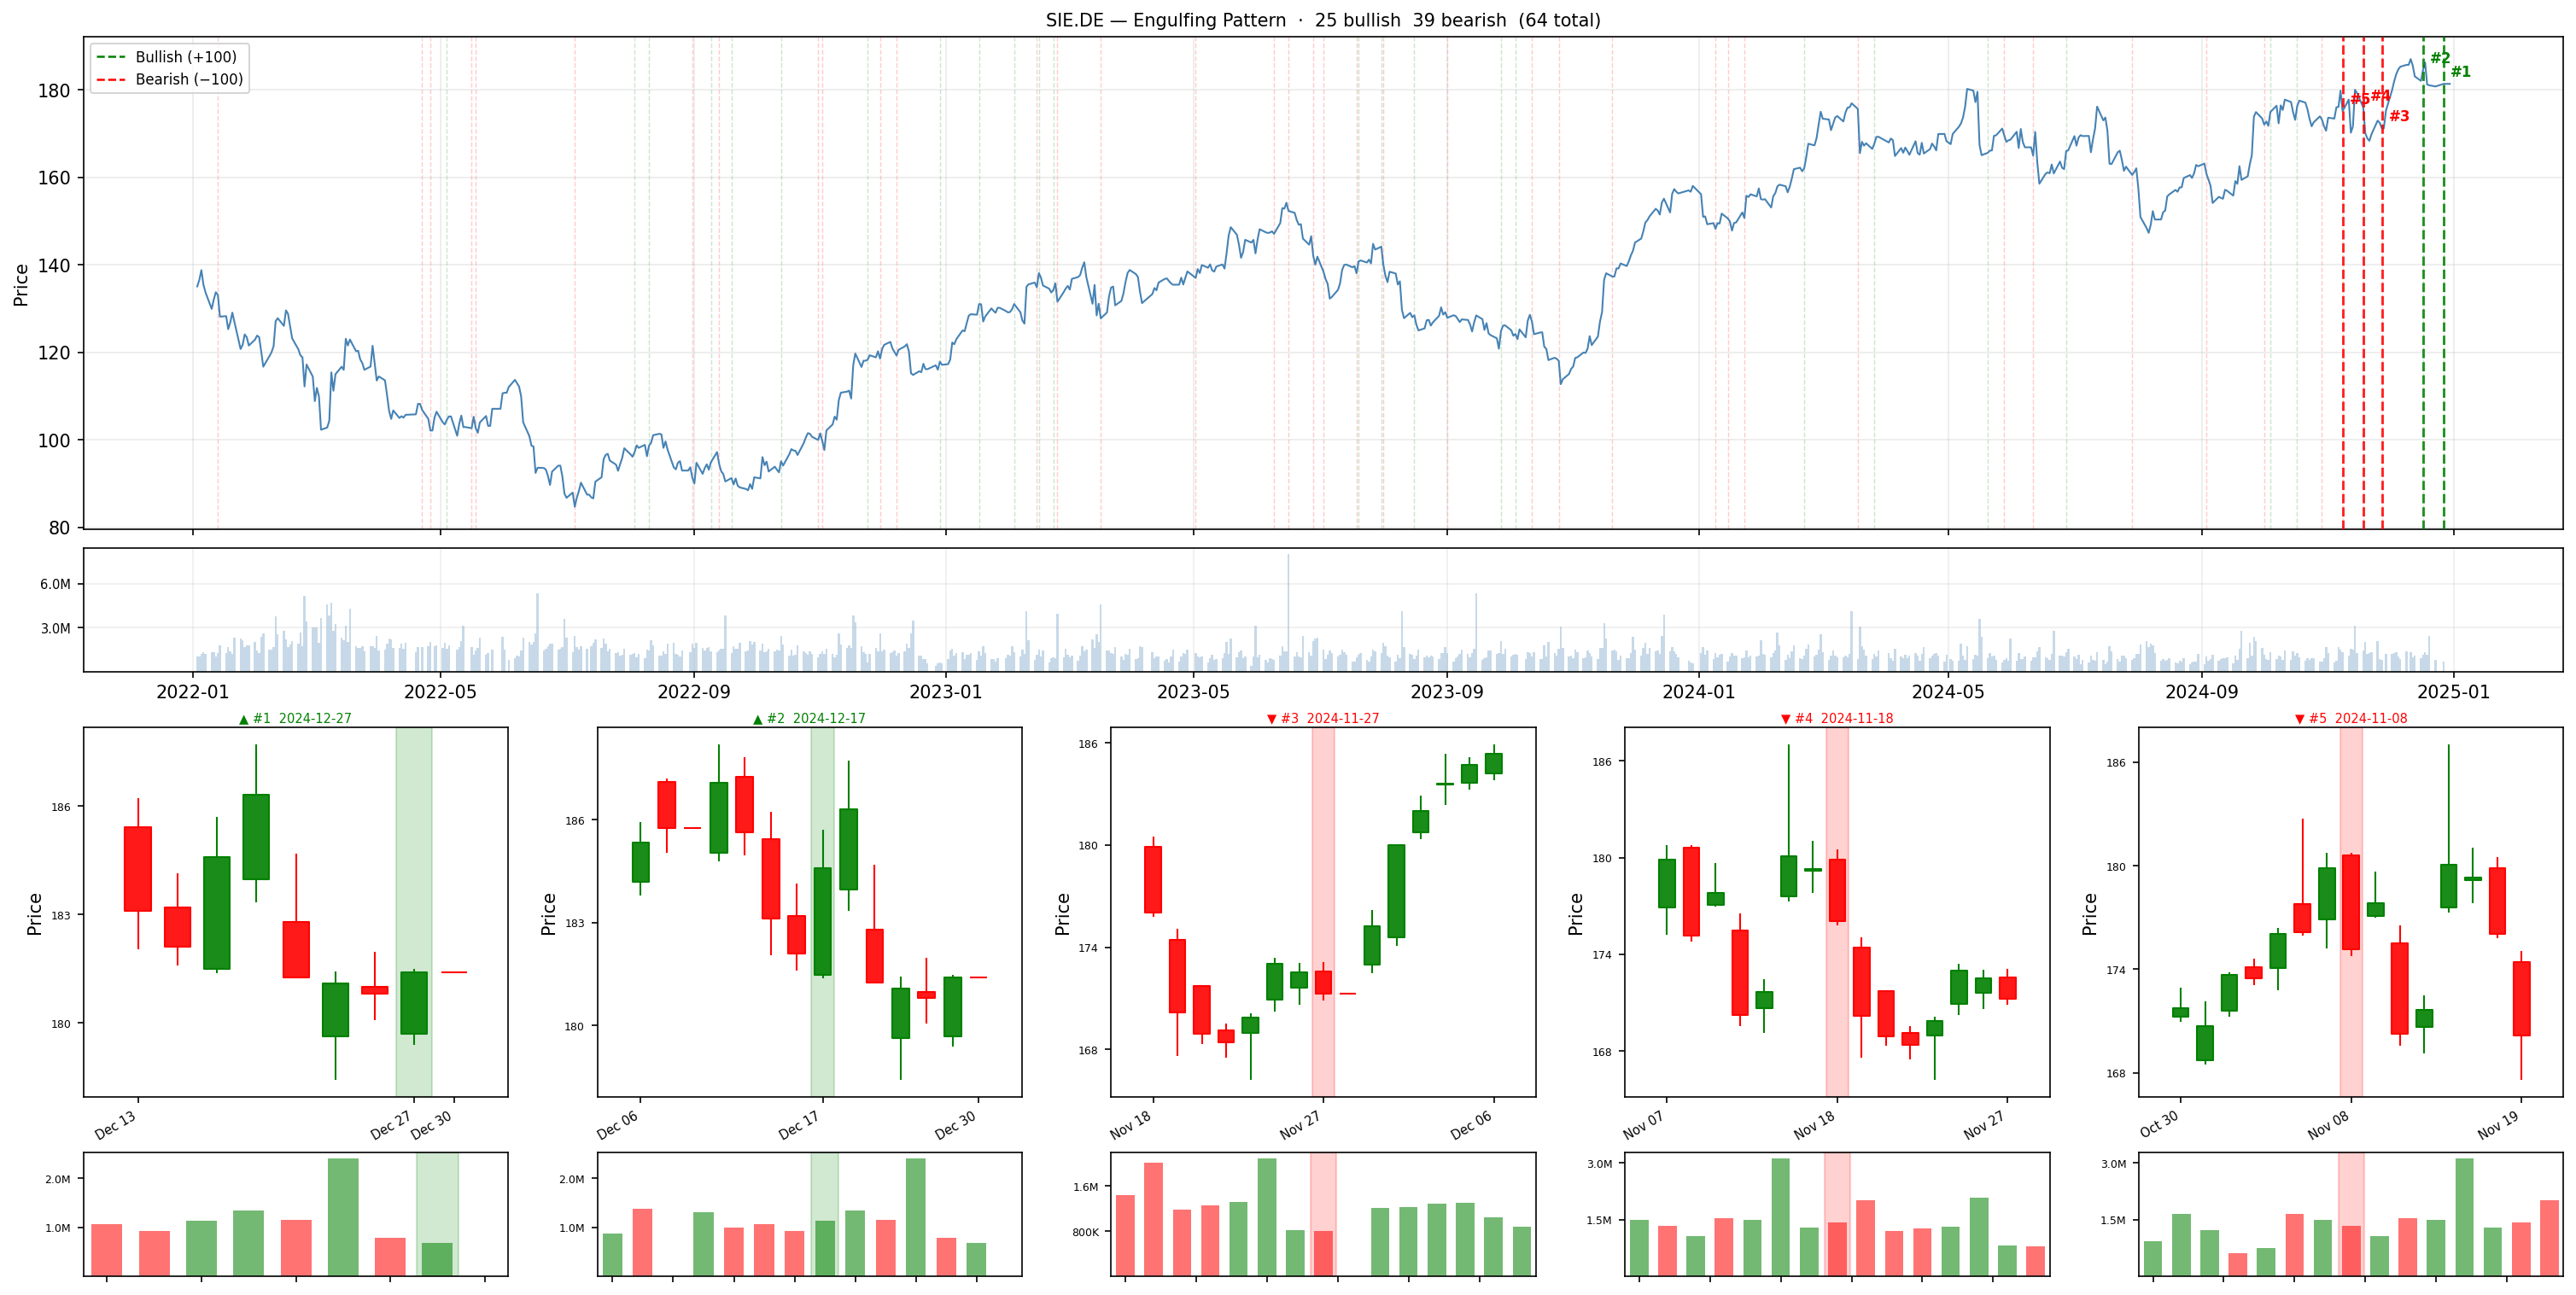

In [12]:
from techa.patterns import plot_pattern

os.makedirs("charts", exist_ok=True)

plot_pattern(
    ohlcv["SIE.DE"], "CDLENGULFING",
    symbol="SIE.DE",
    signal_filter="all",
    window_bars=7,
    max_occurrences=5,
    show_volume=True,
    output="save",
    output_dir="charts",
)
display(Image("charts/CDLENGULFING.png"))

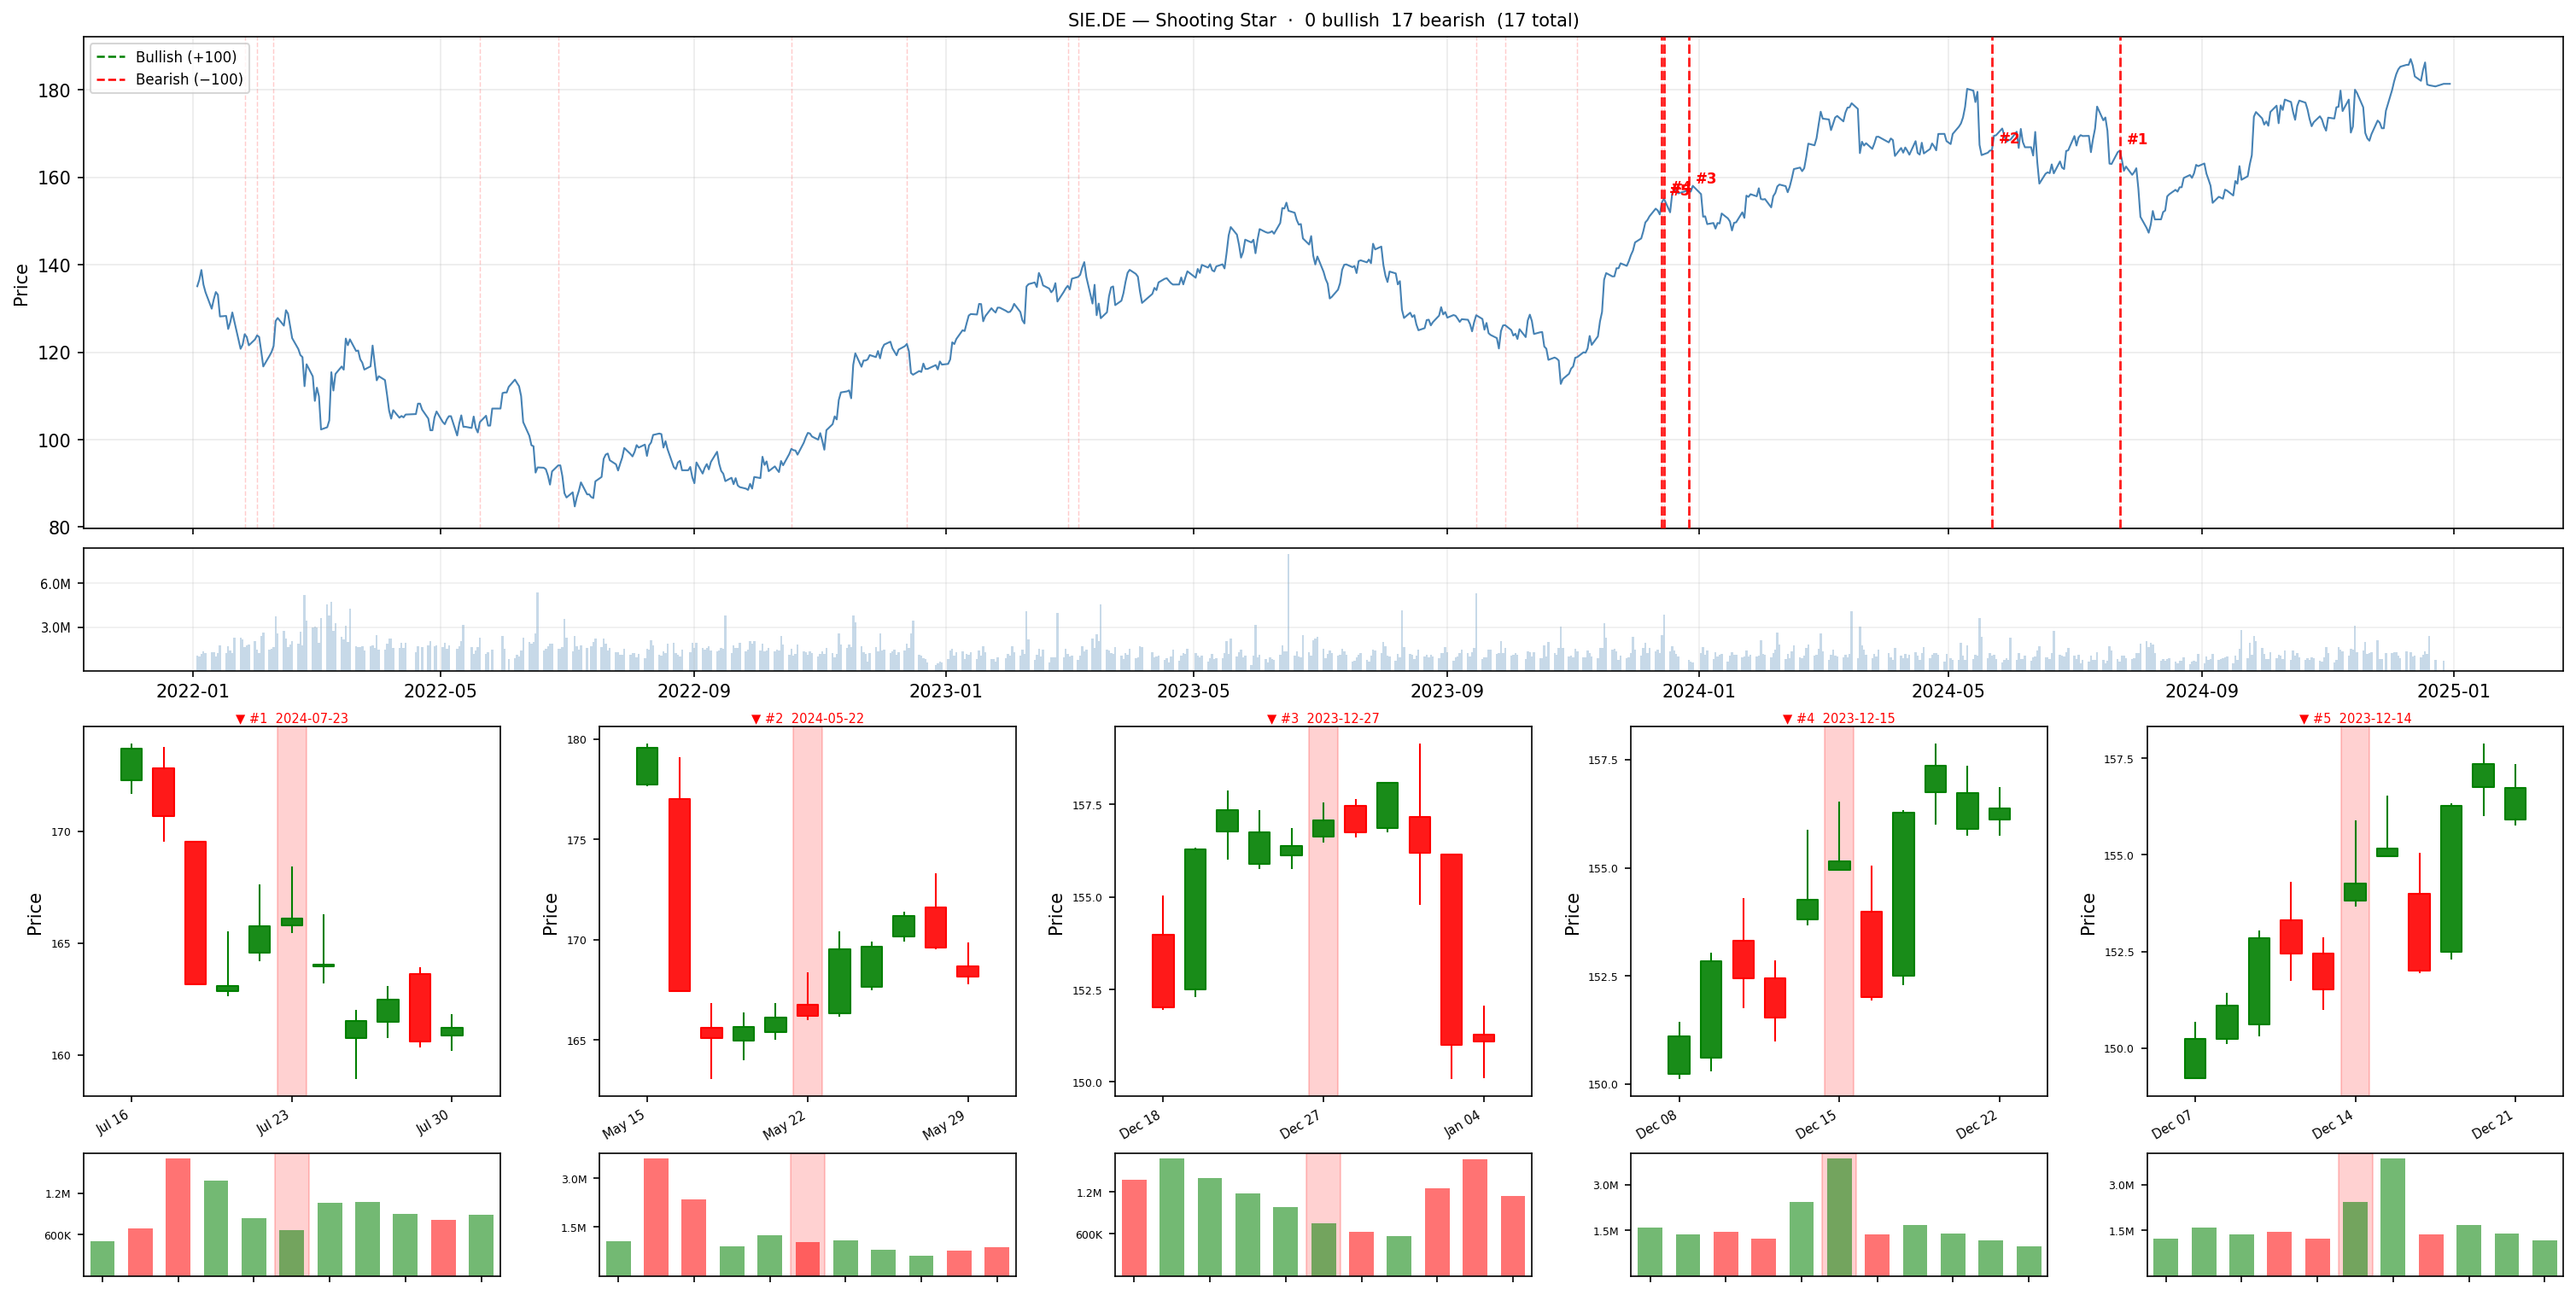

In [13]:
# Bearish signals only for Shooting Star
plot_pattern(
    ohlcv["SIE.DE"], "CDLSHOOTINGSTAR",
    symbol="SIE.DE",
    signal_filter="bear",
    window_bars=5,
    output="save",
    output_dir="charts",
)
if os.path.exists("charts/CDLSHOOTINGSTAR.png"):
    display(Image("charts/CDLSHOOTINGSTAR.png"))
else:
    print("CDLSHOOTINGSTAR — no bearish signals in this date range.")

### 3.4 — `explore_patterns`

Batch version of `plot_pattern` — one figure per pattern that fired at least once.
Patterns with zero matches are silently skipped.

Pass `patterns=` to check a subset; omit it to scan all 61.
With `output="save"` each figure is written to `output_dir/{TALIB_NAME}.png`.


CDLENGULFING


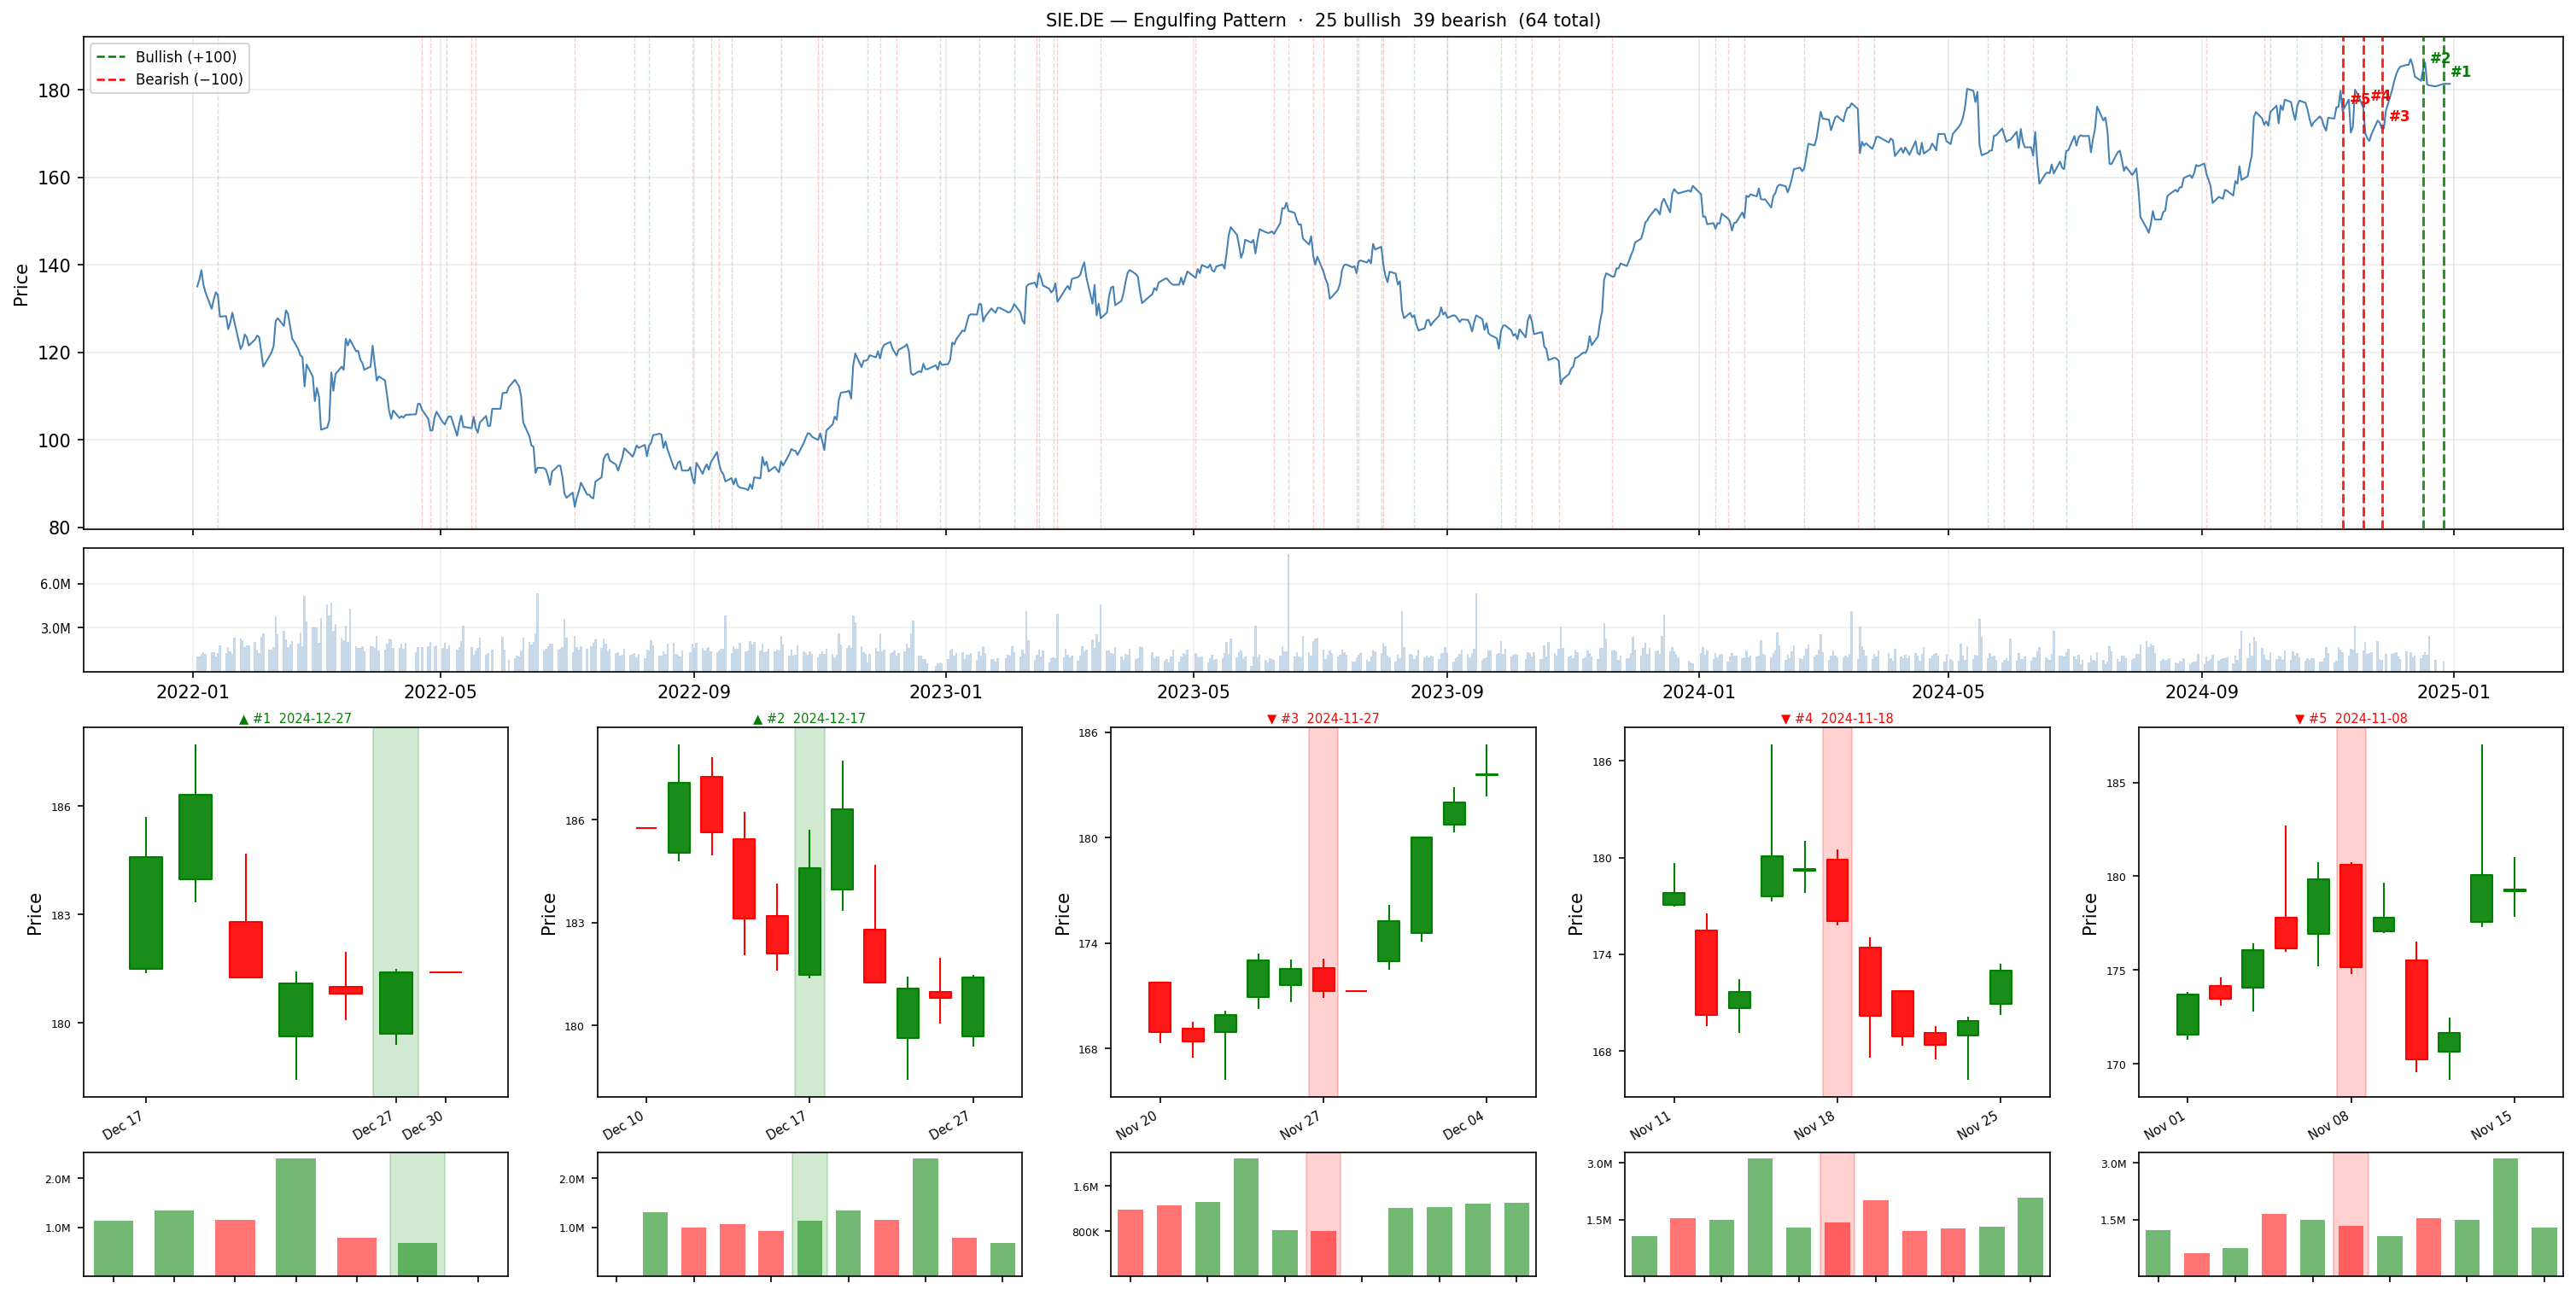


CDLMORNINGSTAR


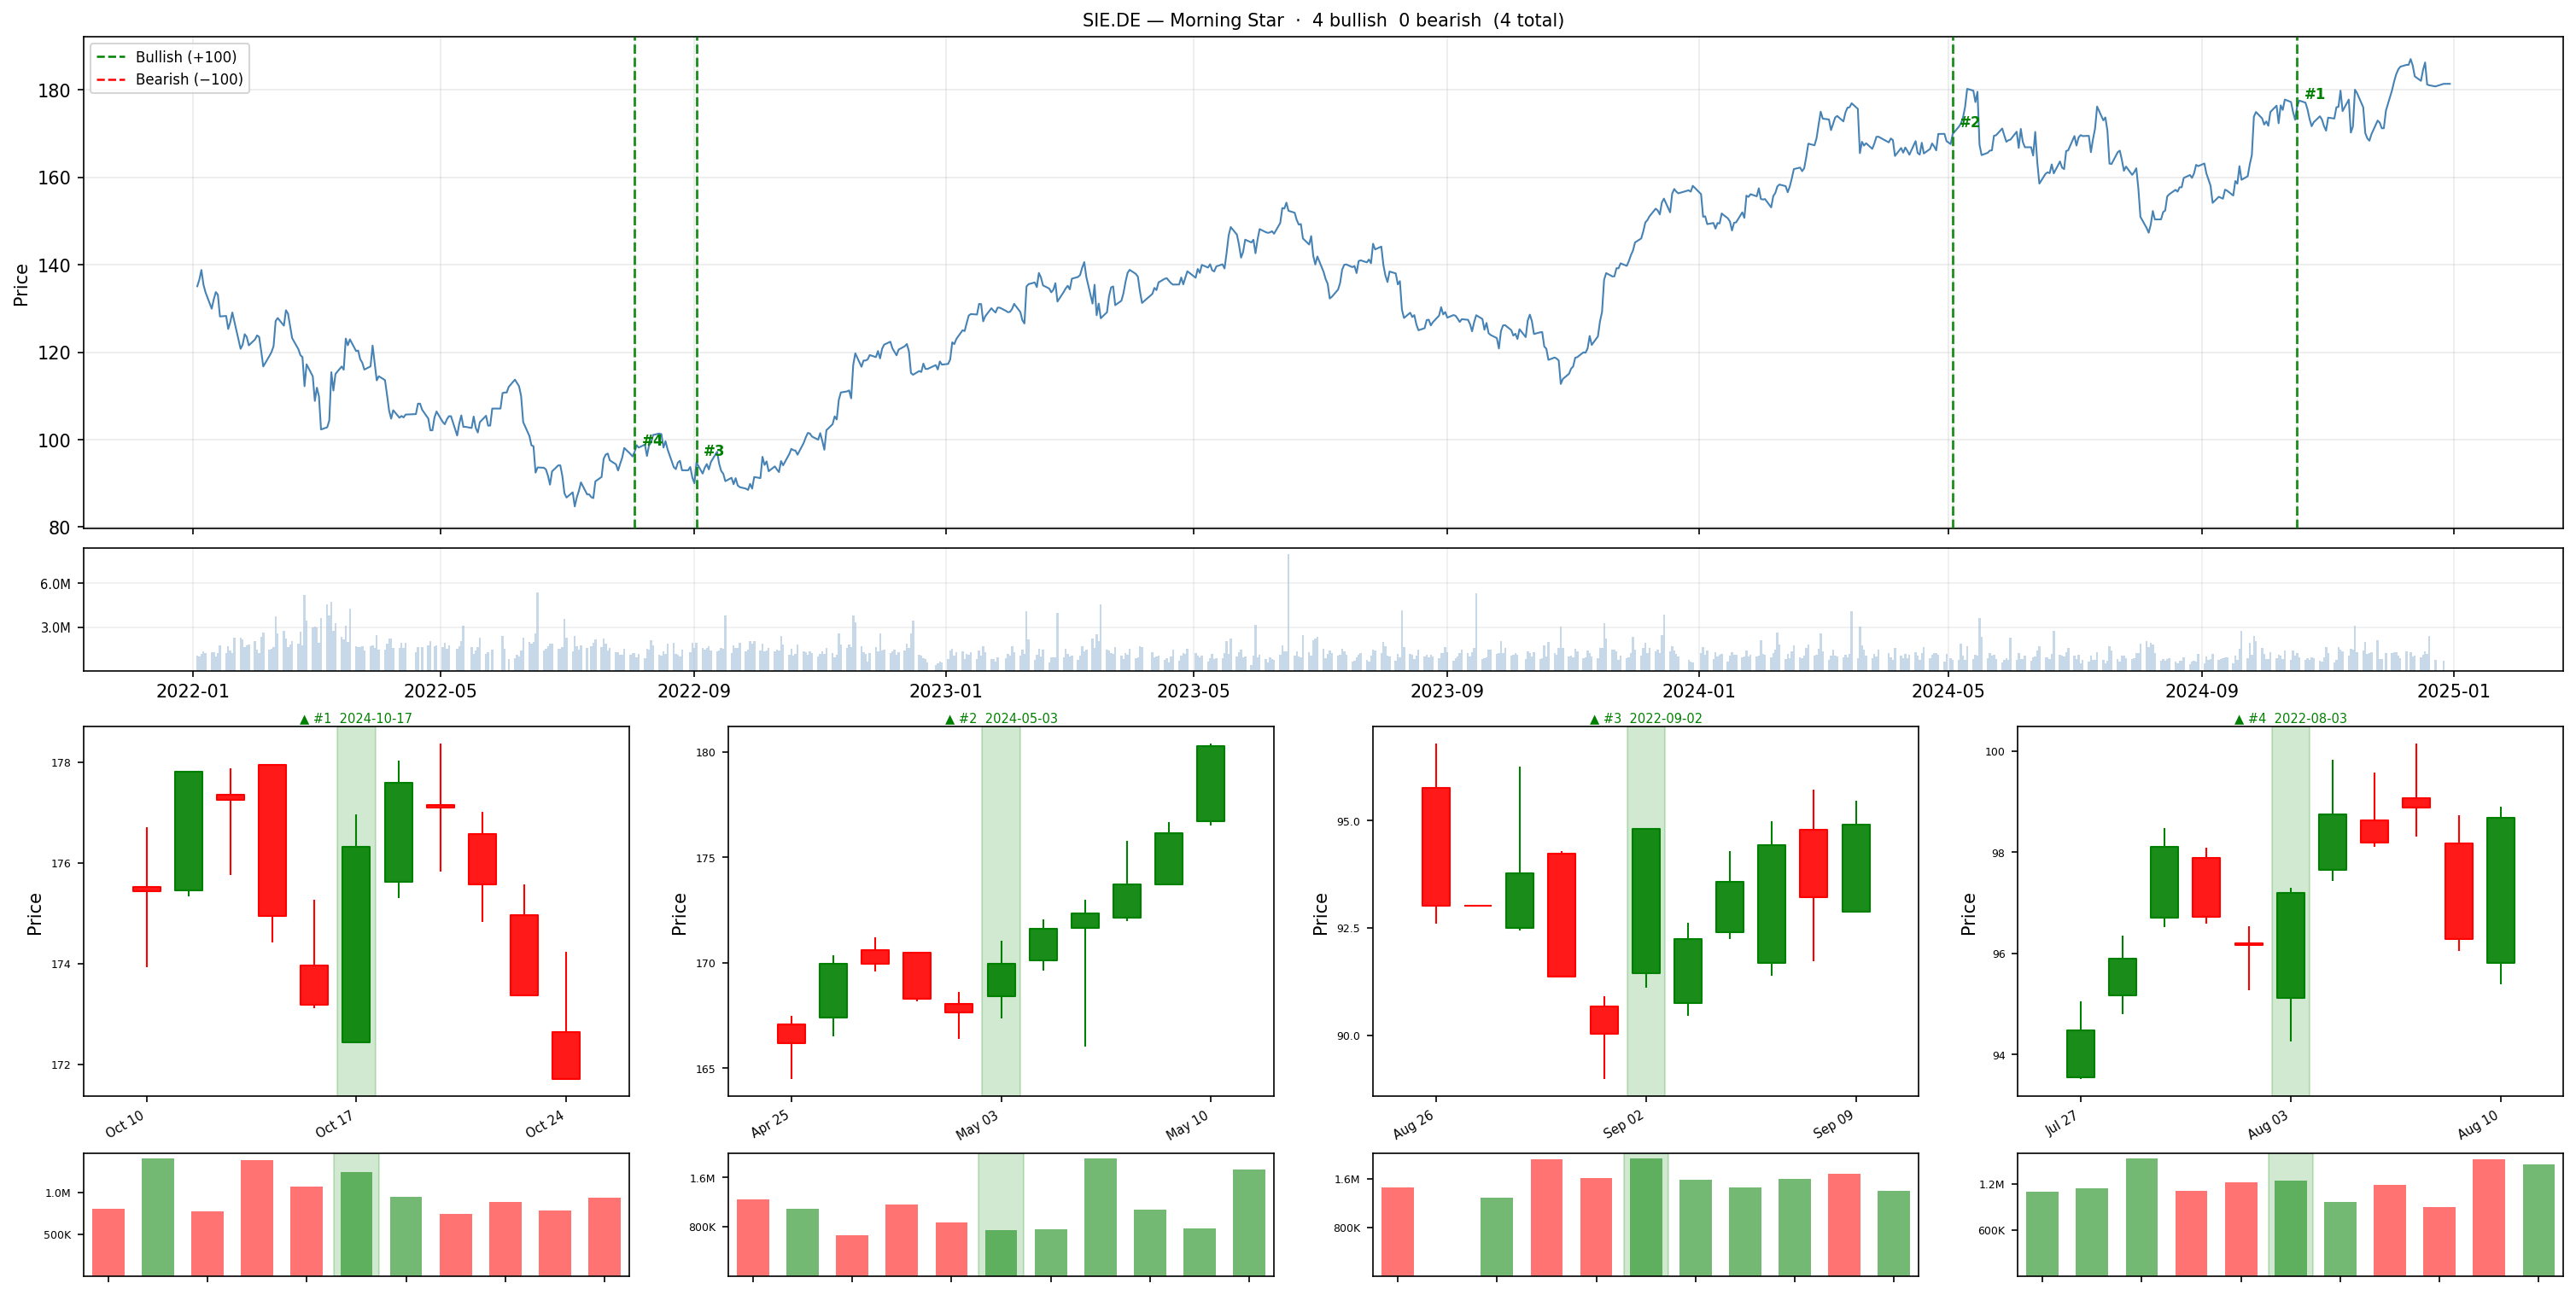


CDLEVENINGSTAR


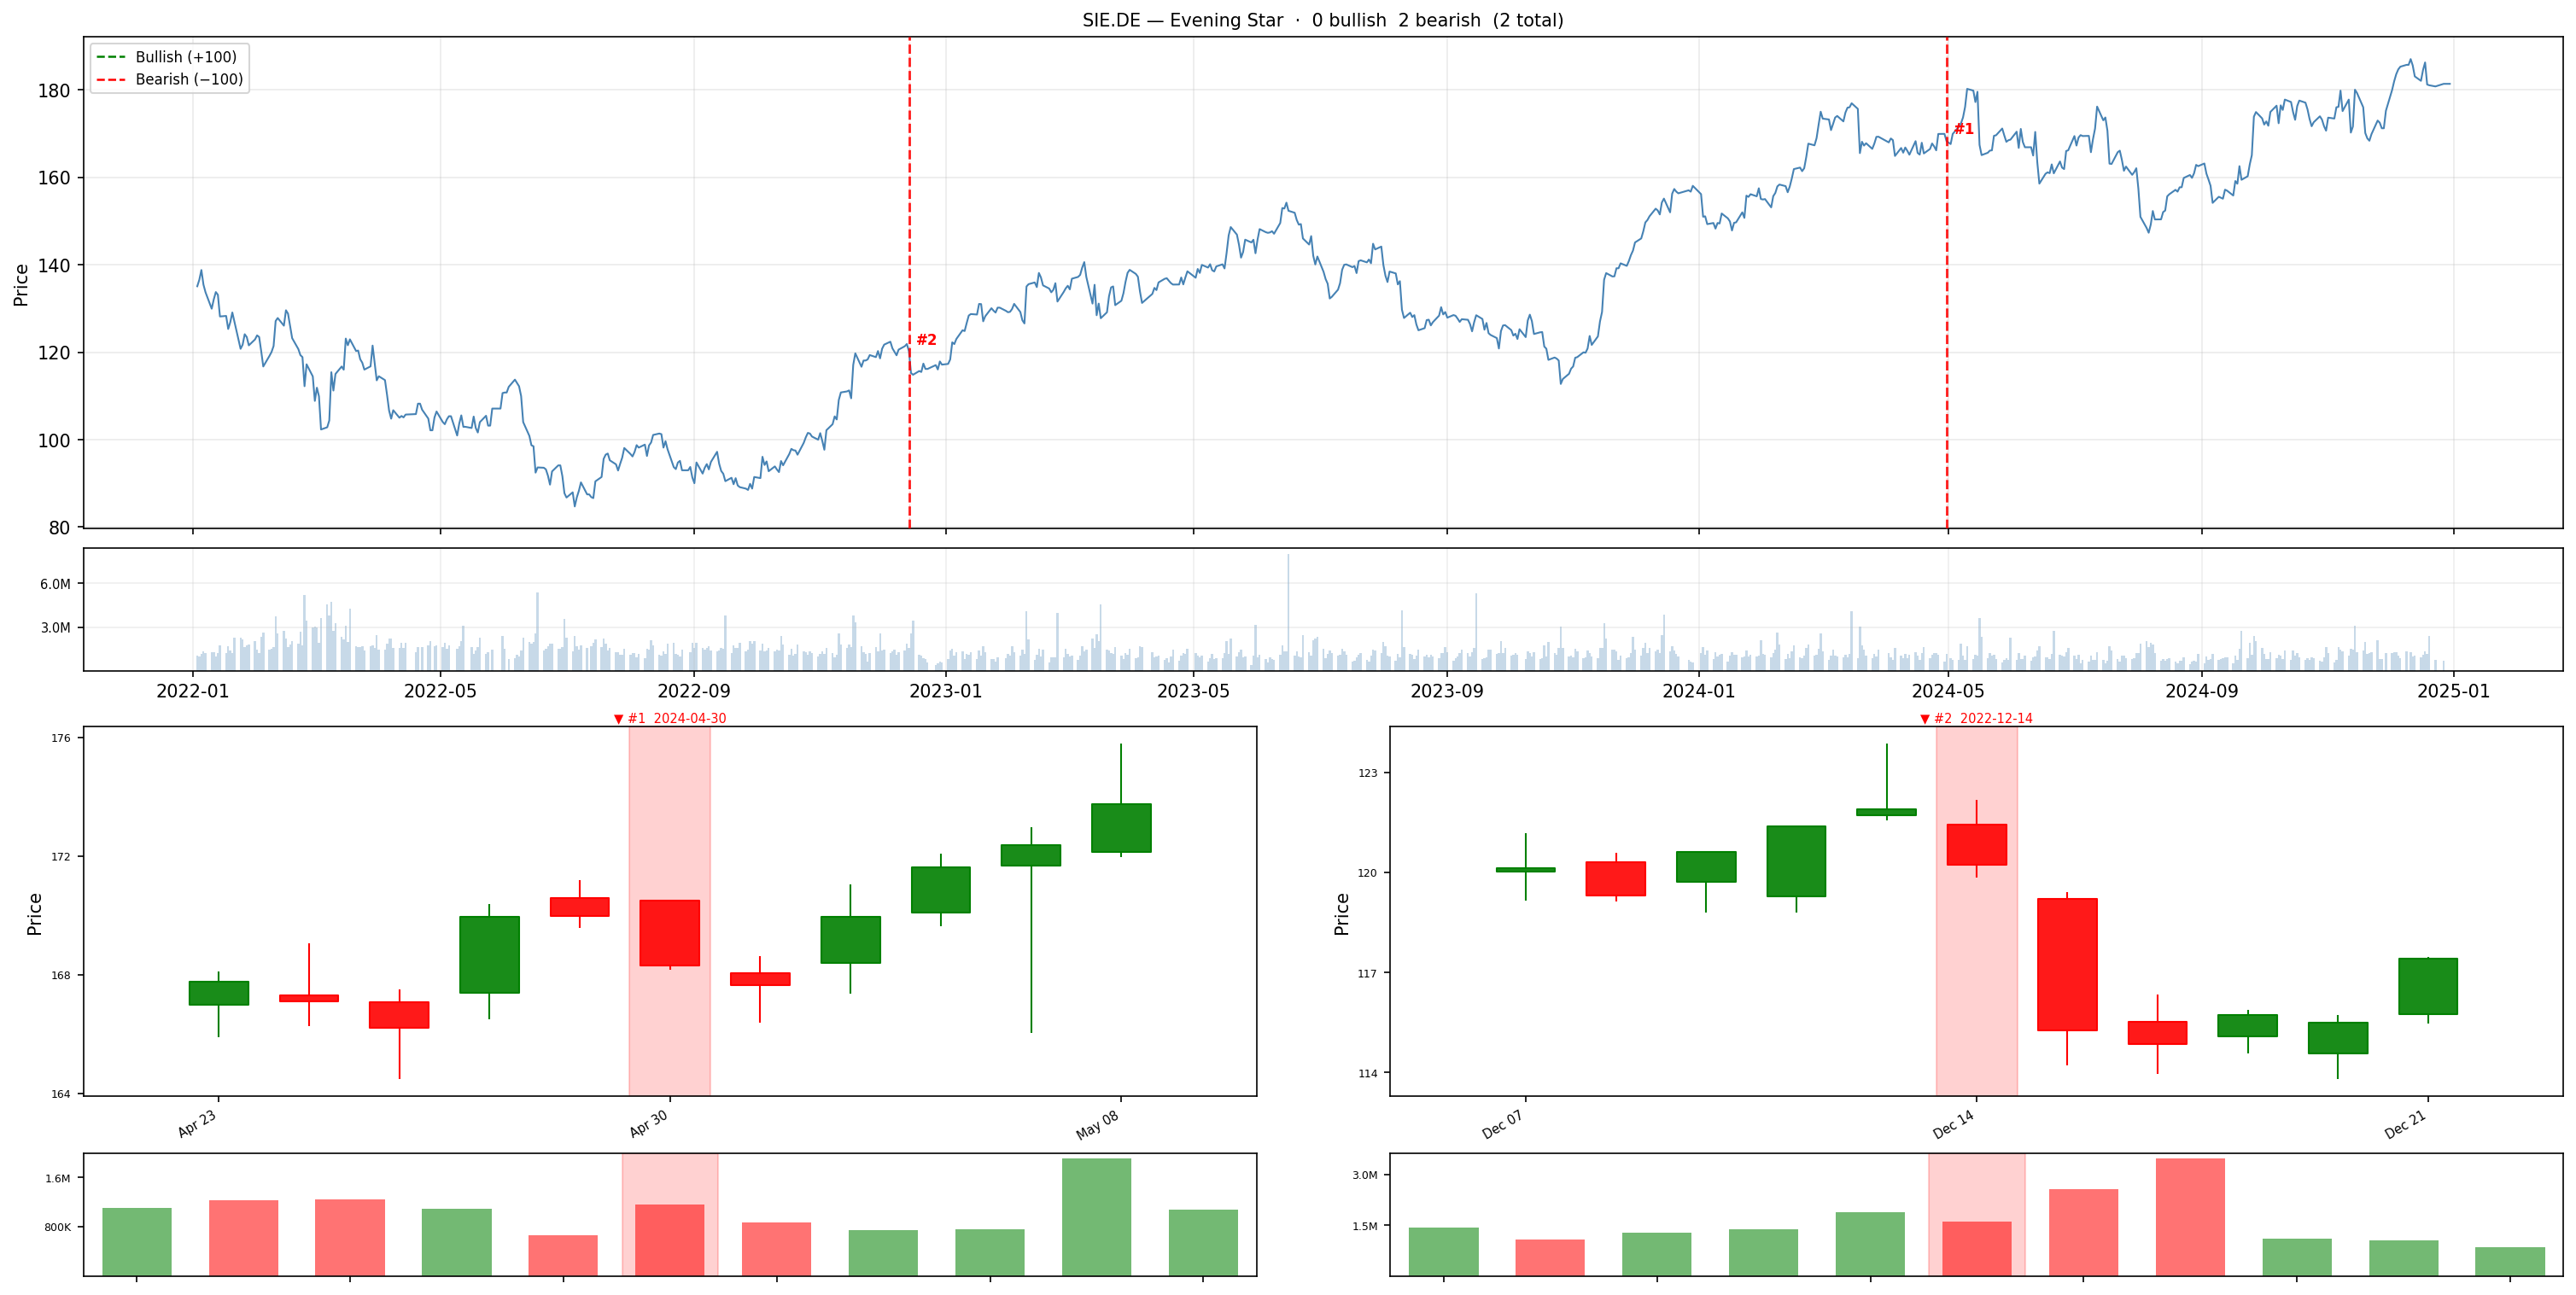


CDLHAMMER


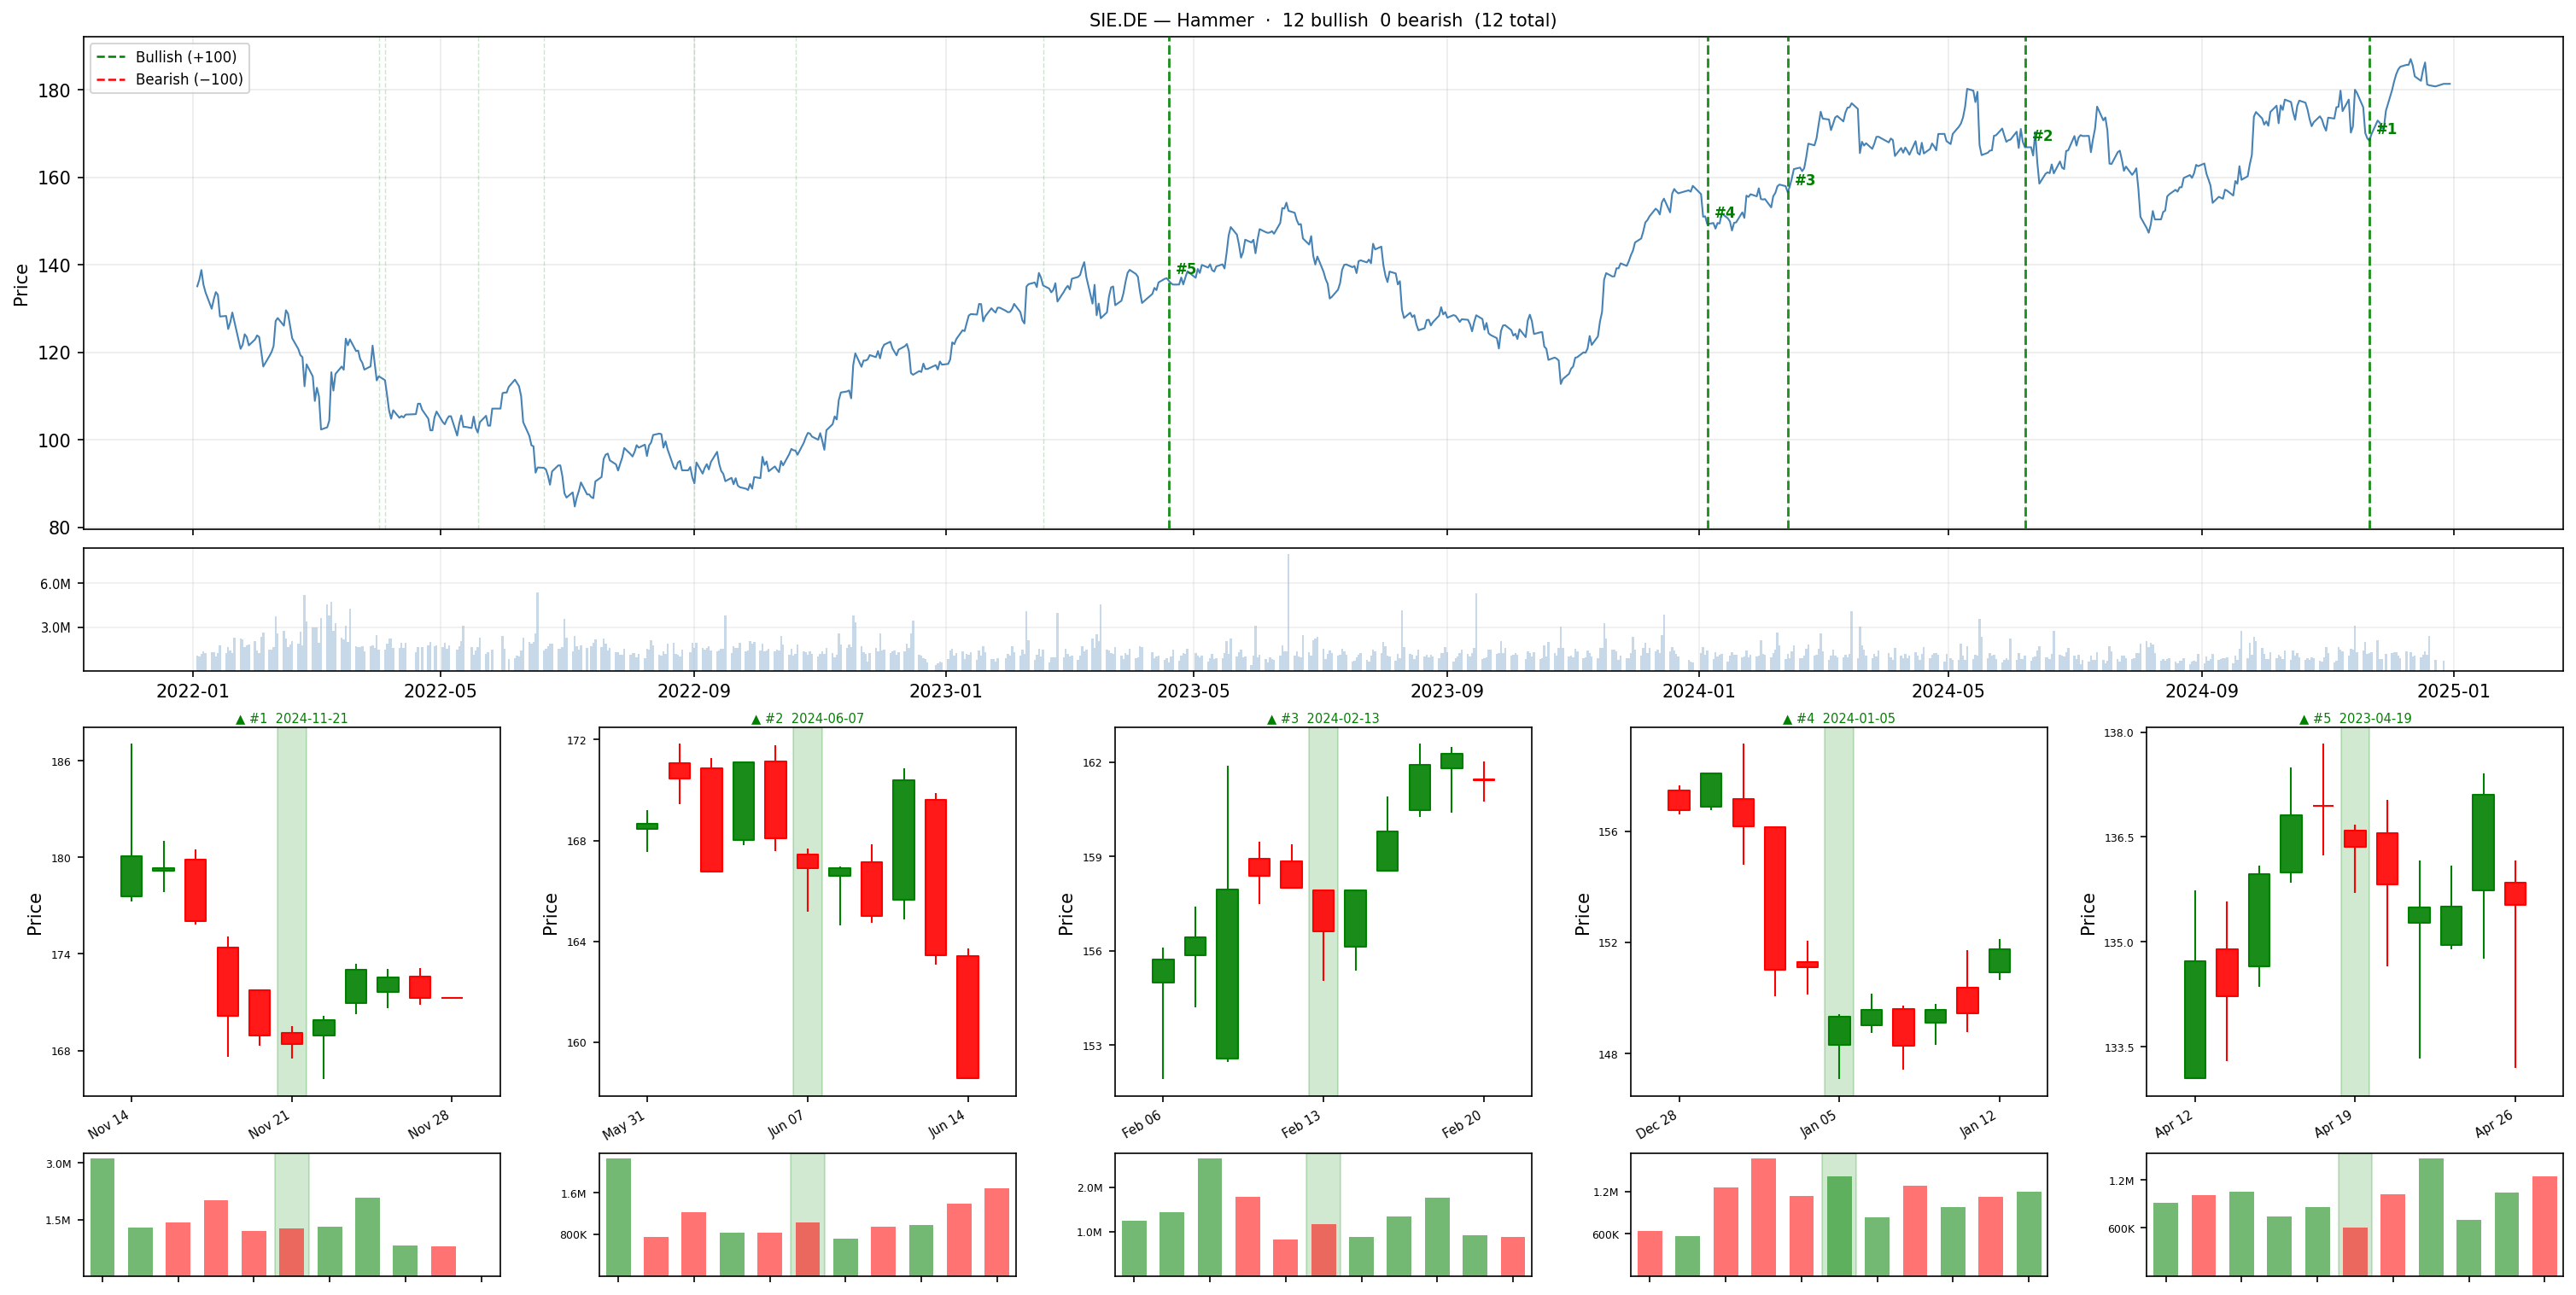


CDLSHOOTINGSTAR


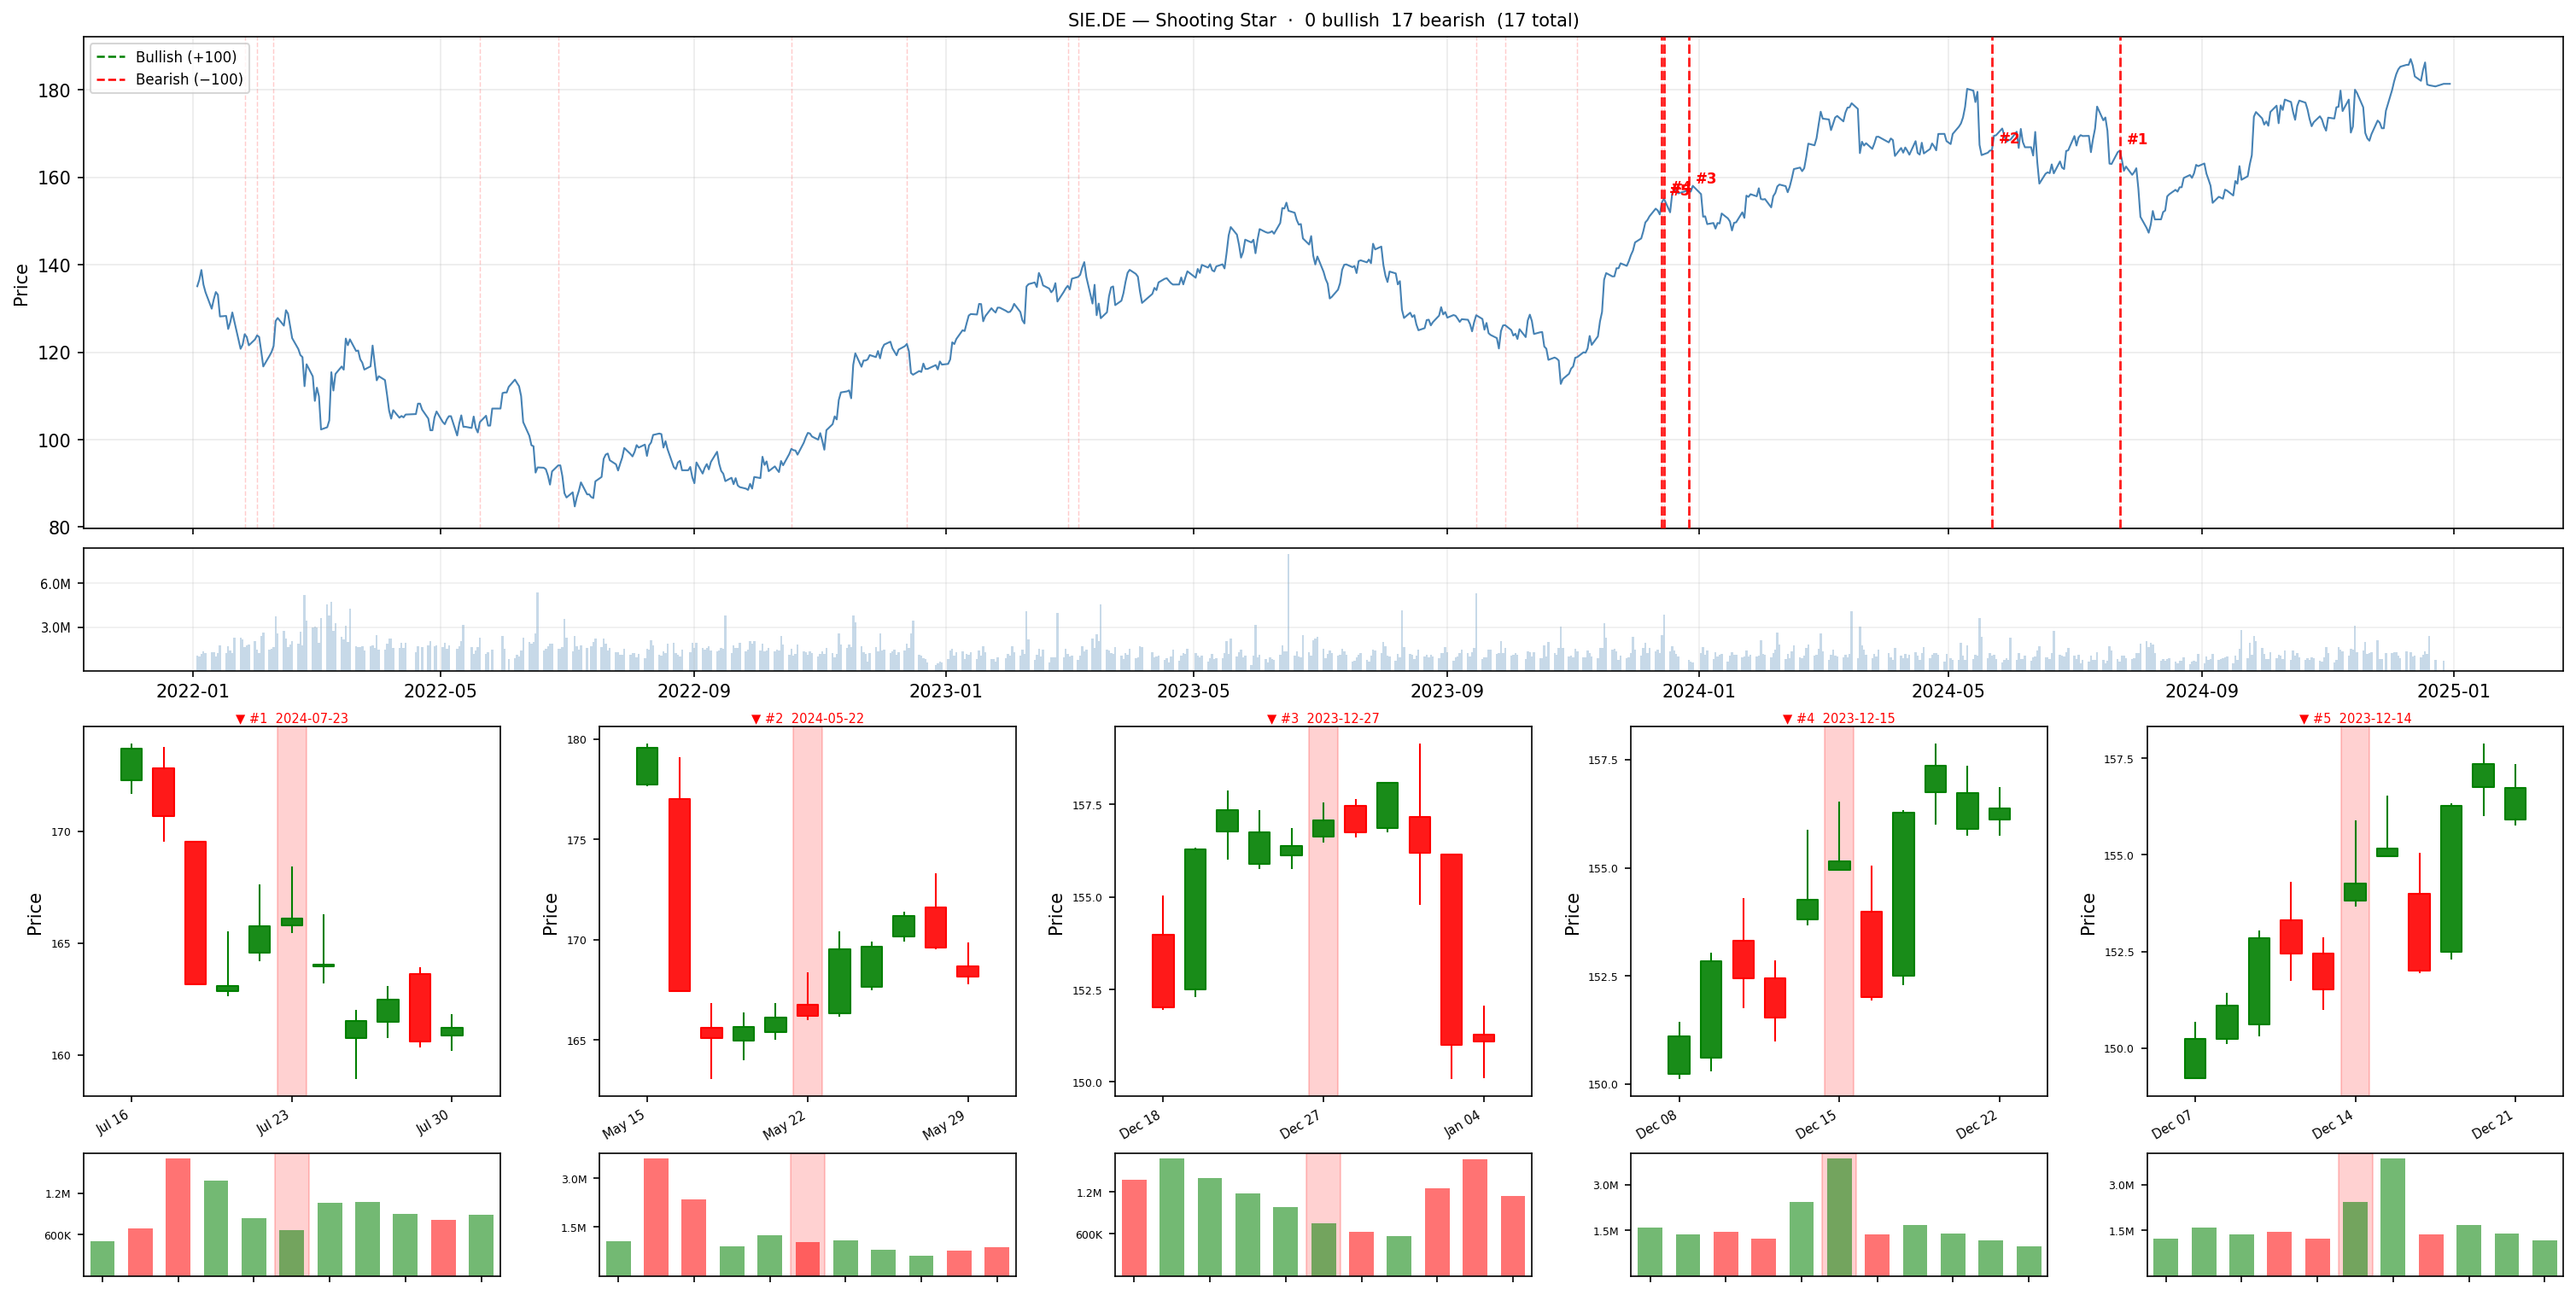

In [14]:
from techa.patterns import explore_patterns

watch_patterns = [
    "CDLENGULFING", "CDLMORNINGSTAR", "CDLEVENINGSTAR",
    "CDLHAMMER",    "CDLSHOOTINGSTAR",
]

explore_patterns(
    ohlcv["SIE.DE"],
    patterns=watch_patterns,
    symbol="SIE.DE",
    output="save",
    output_dir="charts",
)

# Display every saved chart inline
for p in watch_patterns:
    path = f"charts/{p}.png"
    if os.path.exists(path):
        print(f"\n{p}")
        display(Image(path))

## 4 — Morning Routine (Combined)

Combine `scan_last_bar` (what patterns fired last night?) with `build_snapshot`
(is the indicator context favourable?) to produce a pre-market watchlist.

A pattern hit is more actionable when:
- `adx` > 25 (trending market)
- `rsi_zone` matches signal direction (oversold + bullish, or overbought + bearish)
- `vol_vs_ma20` > 1.2 (volume confirmed the pattern bar)
- `slope_sma20_r2` > 0.3 (trend is directional, not noise)

In [15]:
from techa.indicators import build_snapshot
from techa.patterns import scan_last_bar

# Step 1: which patterns fired last night?
nightly = scan_last_bar(ohlcv)

if nightly.empty:
    print("No patterns fired on the last bar — nothing to act on.")
else:
    # Step 2: enrich each hit with indicator context
    rows = []
    for _, hit in nightly.iterrows():
        ticker = hit["ticker"]
        snap   = build_snapshot(ohlcv[ticker], nan_to_none=True)
        rows.append({
            "ticker":       ticker,
            "pattern":      hit["display_name"],
            "direction":    "▲ Bull" if hit["signal"] > 0 else "▼ Bear",
            "price":        round(snap["price"], 2),
            "rsi":          round(snap["rsi"] or 0, 1),
            "rsi_zone":     snap["rsi_zone"],
            "adx":          round(snap["adx"] or 0, 1),
            "vol_vs_ma20":  round(snap["vol_vs_ma20"] or 0, 2),
            "slope_r2":     round(snap["slope_sma20_r2"] or 0, 2),
            "golden_cross": snap["golden_cross"],
        })

    watchlist = pd.DataFrame(rows)
    print("─── Pre-market watchlist ───")
    display(watchlist)

    # Quick context filter — high-conviction candidates
    if len(watchlist):
        conviction = watchlist[
            (watchlist["adx"]        > 25) &
            (watchlist["vol_vs_ma20"] > 1.2) &
            (watchlist["slope_r2"]    > 0.3)
        ]
        print(f"\n─── High-conviction hits ({len(conviction)}) ───")
        display(conviction)

─── Pre-market watchlist ───


,ticker,pattern,direction,price,rsi,rsi_zone,adx,vol_vs_ma20,slope_r2,golden_cross
0,SIE.DE,Doji,▲ Bull,181.41,52.3,neutral,25.4,0.00,0.99,True
1,SIE.DE,Harami Cross Pattern,▼ Bear,181.41,52.3,neutral,25.4,0.00,0.99,True
2,SIE.DE,Short Line Candle,▲ Bull,181.41,52.3,neutral,25.4,0.00,0.99,True
3,SIE.DE,Harami Pattern,▼ Bear,181.41,52.3,neutral,25.4,0.00,0.99,True
4,STMMI.MI,Closing Marubozu,▼ Bear,23.56,46.0,neutral,13.5,0.60,0.81,False
5,STMMI.MI,Long Line Candle,▼ Bear,23.56,46.0,neutral,13.5,0.60,0.81,False
6,STMMI.MI,Marubozu,▼ Bear,23.56,46.0,neutral,13.5,0.60,0.81,False
7,STMMI.MI,Belt-hold,▼ Bear,23.56,46.0,neutral,13.5,0.60,0.81,False
8,STMMI.MI,Tasuki Gap,▲ Bull,23.56,46.0,neutral,13.5,0.60,0.81,False
9,PRY.MI,High-Wave Candle,▲ Bull,60.11,46.6,neutral,15.9,0.47,0.16,True



─── High-conviction hits (0) ───


,ticker,pattern,direction,price,rsi,rsi_zone,adx,vol_vs_ma20,slope_r2,golden_cross


## 5 — Error Handling

| Function | Condition | Error |
|---|---|---|
| `build_snapshot` | < 30 bars | `ValueError` |
| `build_snapshot` | Missing OHLCV column | `ValueError` |
| `build_snapshot_from_parquet` | File not found | `FileNotFoundError` |
| `build_snapshot_from_parquet` | Ticker not in parquet | `ValueError` |
| `build_group_snapshot` | Non-MultiIndex DataFrame input | `ValueError` |
| `scan_patterns` | No patterns fired | Returns empty DataFrame (no error) |

In [16]:
from techa.indicators import build_snapshot, build_snapshot_from_parquet

# 1. Too few bars
short_df = ohlcv["SIE.DE"].tail(10)
try:
    build_snapshot(short_df)
except ValueError as e:
    print(f"Too few bars     → {e}")

# 2. Missing OHLCV column
no_volume = ohlcv["SIE.DE"].drop(columns=["Volume"])
try:
    build_snapshot(no_volume)
except ValueError as e:
    print(f"Missing column   → {e}")

# 3. Parquet not found
try:
    build_snapshot_from_parquet("SIE.DE", "nonexistent.parquet")
except FileNotFoundError as e:
    print(f"Parquet missing  → {e}")

# 4. Ticker absent from parquet — needs a real parquet; shown for reference
# try:
#     build_snapshot_from_parquet("UNKNOWN.MI", "data/ohlcv.parquet")
# except ValueError as e:
#     print(f"Ticker not found → {e}")

# 5. scan_patterns — no match returns empty DataFrame, not an error
from techa.patterns import scan_patterns
empty = scan_patterns(
    ohlcv["SIE.DE"],
    patterns=["CDLABANDONEDBABY"],
    signal_filter="bull",
)
print(f"\nscan_patterns empty result → DataFrame with {len(empty)} rows, columns: {list(empty.columns)}")

Too few bars     → build_snapshot requires at least 30 bars; got 10. Provide a longer history or lower MIN_BARS in _adapter.py.
Missing column   → build_snapshot: missing required OHLCV columns: ['volume']. Got: ['close', 'high', 'low', 'open'].
Parquet missing  → Parquet not found: nonexistent.parquet

scan_patterns empty result → DataFrame with 0 rows, columns: ['date', 'talib_name', 'display_name', 'signal']
